# LLM-as-Judge Signal – Evaluation & Analysis

This notebook evaluates the **LLM-as-Judge** signal used in our hallucination detection system.

Unlike semantic similarity, which uses vector distance, this signal uses a Large Language Model to actively "reason" about the relationship between the answer and the context.

**Objectives:**
- Quantify the performance of the LLM Judge (Precision, Recall, F1)
- Analyze score distributions (Are valid/hallucinated scores well-separated?)
- Inspect the Judge's text explanations for False Positives/Negatives
- Determine the optimal decision threshold

In [1]:
import json
import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  
import seaborn as sns
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# Import the Judge
# We append ".." to path so we can import from the 'src' directory
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.detection.llm_judge import llm_judge

# Set plot style
sns.set_style("whitegrid")

## 2. Load Dataset
We use the same `preliminary_hallucination_dataset.json` containing 90 labeled QA pairs.

In [2]:
DATA_PATH = "../data/preliminary_hallucination_dataset.json"

with open(DATA_PATH, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Convert labels to binary (1 = Hallucinated, 0 = Valid)
df["label_binary"] = df["label"].map({
    "valid": 0,
    "hallucinated": 1
})

print(f"Loaded {len(df)} examples.")
df.head()

Loaded 90 examples.


,question_id,question,context,answer,label,hallucination_type,label_binary
0,1,Does metformin reduce hepatic glucose producti...,"[{'doc_id': 'doc1', 'text': 'Metformin lowers ...",Yes. Metformin reduces hepatic glucose product...,valid,none,0
1,2,Is smoking a major risk factor for lung cancer?,"[{'doc_id': 'doc1', 'text': 'Smoking is the le...",Yes. Smoking is a major risk factor for lung c...,valid,none,0
2,3,Do statins inhibit HMG-CoA reductase?,"[{'doc_id': 'doc1', 'text': 'Statins inhibit H...",Yes. Statins inhibit HMG-CoA reductase [doc1].,valid,none,0
3,4,Does insulin lower blood glucose levels?,"[{'doc_id': 'doc1', 'text': 'Insulin lowers bl...",Yes. Insulin lowers blood glucose levels [doc1].,valid,none,0
4,5,Is hypertension associated with increased stro...,"[{'doc_id': 'doc1', 'text': 'Hypertension is a...",Yes. Hypertension is associated with increased...,valid,none,0


## 3. Run LLM Judge
Since the judge uses `async` calls, we run this loop asynchronously. 
The judge returns a score (0-1) where:
- **High Score (e.g., 0.9)** = High Faithfulness (Valid)
- **Low Score (e.g., 0.1)** = Low Faithfulness (Hallucinated)

*Note: We invert the score later because our target label is 'Hallucination' (1).*

In [3]:


results = []

print("Running LLM Judge on dataset...")

async def run_evaluation():
    # 1. Create all tasks first (but don't await them)
    tasks = []
    for row in data:
        context_text = "\n".join([c["text"] for c in row["context"]])
        
        tasks.append(
            llm_judge.judge(
                question=row["question"],
                answer=row["answer"],
                context=context_text
            )
        )

    # 2. Run in batches to maximize GPU throughput
    # Adjust batch_size based on your VRAM (5 is safe, 10+ for stronger GPUs)
    batch_size = 5
    
    # 3. Use tqdm to wrap the batch iteration
    for i in tqdm(range(0, len(tasks), batch_size), desc="Processing Batches"):
        batch = tasks[i:i + batch_size]
        
        # Run this batch in parallel on the GPU
        batch_results = await asyncio.gather(*batch)
        
        # Store results
        for idx, judge_result in enumerate(batch_results):
            # Map back to the original data row
            original_idx = i + idx
            if original_idx < len(data):
                row = data[original_idx]
                results.append({
                    "question_id": row["question_id"],
                    "label": row["label"],
                    "label_binary": 1 if row["label"] == "hallucinated" else 0,
                    "hallucination_type": row["hallucination_type"],
                    "judge_score_faithfulness": judge_result["score"],
                    "judge_passed": judge_result["passed"],
                    "explanation": judge_result["details"]
                })

# Run the async loop
await run_evaluation()

res_df = pd.DataFrame(results)
print("\nEvaluation complete.")
res_df.head()

Running LLM Judge on dataset...


Processing Batches:   0%|          | 0/18 [00:00<?, ?it/s]16:32:03 - LiteLLM:INFO: utils.py:3807 - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - 
LiteLLM completion() model= phi3:mini; provider = ollama
16:32:03 - LiteLLM:INFO: utils.py:3807 - 
LiteLLM completion() model= phi3:mini; provider = ollama
16:32:03 - LiteLLM:INFO: utils.py:3807 - 
LiteLLM completion() model= phi3:mini; provider = ollama
16:32:03 - LiteLLM:INFO: utils.py:3807 - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - 
LiteLLM completion() model= phi3:mini; provider = ollama
16:32:03 - LiteLLM:INFO: utils.py:3807 - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - 
LiteLLM completion() model= phi3:mini; provider = ollama
INFO - Judge score: 0.900 (raw: 9.0/10) (PASS, threshold: 0.6)
INFO - Judge score: 0.900 (raw: 9.0/10) (PASS, threshold: 0


Evaluation complete.


,question_id,label,label_binary,hallucination_type,judge_score_faithfulness,judge_passed,explanation
0,1,valid,0,none,0.9,True,"9/10. The answer is faithful to the context, a..."
1,2,valid,0,none,0.9,True,**Rate this answer based on the provided crite...
2,3,valid,0,none,1.0,True,**Rating: 10/10** Explanation: The answer is f...
3,4,valid,0,none,1.0,True,**Rating: 10/10** Explanation: The answer is f...
4,5,valid,0,none,1.0,True,**Rate the answer based on faithfulness to con...


## 4. Signal Processing
The LLM judges "Faithfulness" (higher is better). 
To detect hallucinations (where "1" is bad), we calculate:
$$\text{Hallucination Score} = 1 - \text{Faithfulness Score}$$

In [4]:
# Convert Faithfulness (1=Good) to Hallucination Score (1=Bad)
res_df["hallucination_score"] = 1 - res_df["judge_score_faithfulness"]

# Define a threshold for classification (e.g., score < 0.5 implies hallucination)
THRESHOLD = 0.5
res_df["predicted_hallucination"] = (res_df["hallucination_score"] > THRESHOLD).astype(int)

res_df[["label", "judge_score_faithfulness", "hallucination_score", "predicted_hallucination"]].head()

,label,judge_score_faithfulness,hallucination_score,predicted_hallucination
0,valid,0.9,0.1,0
1,valid,0.9,0.1,0
2,valid,1.0,0.0,0
3,valid,1.0,0.0,0
4,valid,1.0,0.0,0


## 5. Performance Metrics
We evaluate standard classification metrics to see how well the LLM performs.

In [5]:
y_true = res_df["label_binary"]
y_pred = res_df["predicted_hallucination"]

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Valid", "Hallucinated"]))

auc = roc_auc_score(y_true, res_df["hallucination_score"])
print(f"ROC-AUC Score: {auc:.3f}")

Classification Report:

              precision    recall  f1-score   support

       Valid       0.83      1.00      0.91        50
Hallucinated       1.00      0.75      0.86        40

    accuracy                           0.89        90
   macro avg       0.92      0.88      0.88        90
weighted avg       0.91      0.89      0.89        90

ROC-AUC Score: 0.935


## 6. Confusion Matrix
Visualizing False Positives vs. False Negatives.

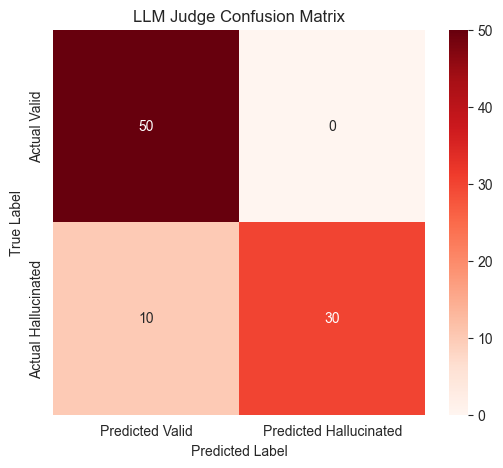

In [6]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Valid', 'Predicted Hallucinated'],
            yticklabels=['Actual Valid', 'Actual Hallucinated'])
plt.title('LLM Judge Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 7. Score Distribution Analysis
Unlike embeddings which produce continuous scores, LLMs often output discrete scores (0.0, 0.5, 1.0).
We visualize this distribution to check for **separation** and **clumping**.

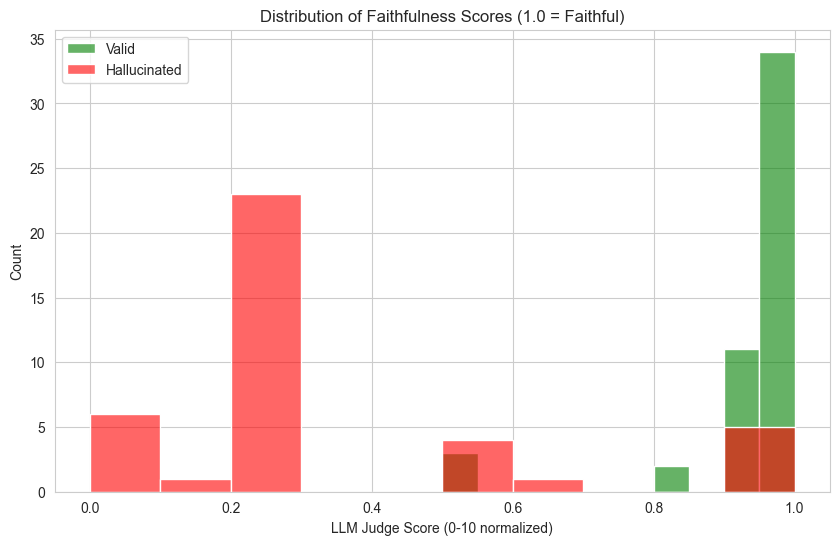

In [7]:
plt.figure(figsize=(10, 6))

# Histogram for Valid Answers
sns.histplot(
    data=res_df[res_df['label'] == 'valid'], 
    x='judge_score_faithfulness', 
    color='green', 
    label='Valid', 
    kde=False, 
    bins=10, 
    alpha=0.6
)

# Histogram for Hallucinated Answers
sns.histplot(
    data=res_df[res_df['label'] == 'hallucinated'], 
    x='judge_score_faithfulness', 
    color='red', 
    label='Hallucinated', 
    kde=False, 
    bins=10, 
    alpha=0.6
)

plt.title('Distribution of Faithfulness Scores (1.0 = Faithful)')
plt.xlabel('LLM Judge Score (0-10 normalized)')
plt.ylabel('Count')
plt.legend()
plt.show()

## 8. Breakdown by Hallucination Type
Which types of hallucinations (e.g., negations, wrong entities) does the LLM catch best?

C:\Users\omarf\AppData\Local\Temp\ipykernel_45672\1246580208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_accuracy.index, y=type_accuracy.values, palette="viridis")


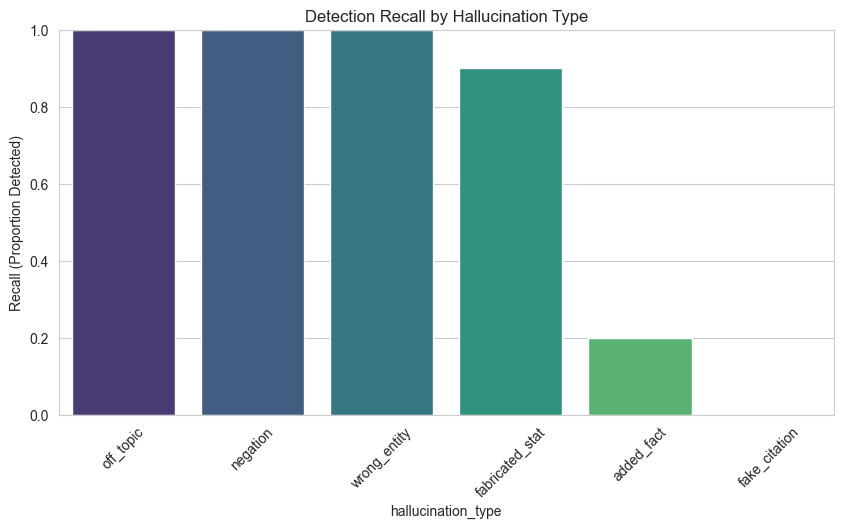

hallucination_type
off_topic          1.0
negation           1.0
wrong_entity       1.0
fabricated_stat    0.9
added_fact         0.2
fake_citation      0.0
Name: predicted_hallucination, dtype: float64

In [8]:
hallucinated_only = res_df[res_df["label"] == "hallucinated"]

type_accuracy = hallucinated_only.groupby("hallucination_type")["predicted_hallucination"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=type_accuracy.index, y=type_accuracy.values, palette="viridis")
plt.title("Detection Recall by Hallucination Type")
plt.ylabel("Recall (Proportion Detected)")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.show()

type_accuracy

## 9. Qualitative Analysis: Explanations
One major advantage of LLM Judges is they provide *reasons* (`details`).
Let's inspect **False Negatives** (Hallucinations the judge missed) to understand why.

In [9]:
false_negatives = res_df[(res_df["label_binary"] == 1) & (res_df["predicted_hallucination"] == 0)]

print(f"Total False Negatives: {len(false_negatives)}\n")

for i, row in false_negatives.head(5).iterrows():
    print(f"ID: {row['question_id']} | Type: {row['hallucination_type']}")
    print(f"Judge Score: {row['judge_score_faithfulness']:.2f} (High faithfulness, but was hallucinated)")
    print(f"Explanation: {row['explanation']}")
    print("-" * 80)

Total False Negatives: 10

ID: 53 | Type: fabricated_stat
Judge Score: 0.50 (High faithfulness, but was hallucinated)
Explanation: **Rate this answer as faithful to the context.** ✓ No contradictions with context - The statement does not directly oppose any information in the original statements about smoking increasing lung cancer risk or its high mortality rates, although it introduces a specific percentage which is unsupported by provided data. ✅ ✓ Information added from outside context – There's no additional factual content introduced that isn’t implied within the given context; however, there seems to be an assumption about causation and quantification not explicitly stated in either original statement. ❌ (Note: The answer assumes a direct link between smoking and mortality increase without mentioning risk or stating it as 'increases' rather than 'raises', which could mislead.) ✓ Numbers/entities accurately match – While the entities are correct, there is no specific number provi

## 10. Threshold Tuning
Does changing the decision threshold improve F1 score?

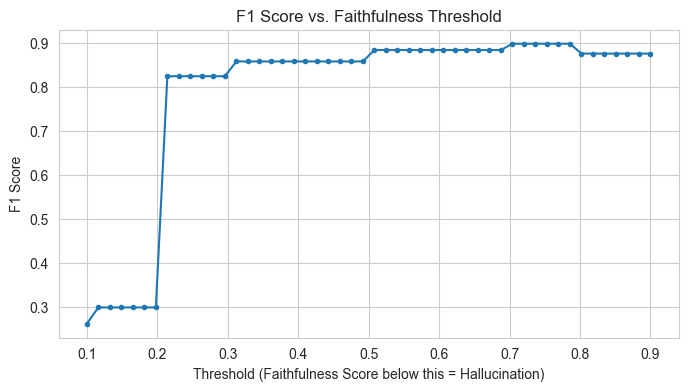

Optimal Threshold: 0.70 (Max F1: 0.897)


In [10]:
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    # Hallucination if Faithfulness < t
    preds = (res_df["judge_score_faithfulness"] < t).astype(int)
    f1_scores.append(f1_score(y_true, preds))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o', markersize=3)
plt.title("F1 Score vs. Faithfulness Threshold")
plt.xlabel("Threshold (Faithfulness Score below this = Hallucination)")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

best_t = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {best_t:.2f} (Max F1: {max(f1_scores):.3f})")